In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [3]:
df.shape

(7043, 33)

In [5]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [6]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['Churn Label'].value_counts(normalize=True)*100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
Online Security         0
CLTV                    0
Churn Score             0
Churn Value             0
Churn Label             0
Total Charges           0
Monthly Charges         0
Payment Method          0
Paperless Billing       0
Contract                0
Streaming Movies        0
Streaming TV            0
Tech Support            0
Device Protection       0
Online Backup           0
CustomerID              0
Count                   0
Multiple Lines          0
Phone Service           0
Tenure Months           0
Dependents              0
Partner                 0
Senior Citizen          0
Gender                  0
Longitude               0
Latitude                0
Lat Long                0
Zip Code                0
City                    0
State                   0
Country                 0
Internet Service        0
dtype: int64

In [9]:
for col in df.columns:
    print(col, df[col].nunique())

CustomerID 7043
Count 1
Country 1
State 1
City 1129
Zip Code 1652
Lat Long 1652
Latitude 1652
Longitude 1651
Gender 2
Senior Citizen 2
Partner 2
Dependents 2
Tenure Months 73
Phone Service 2
Multiple Lines 3
Internet Service 3
Online Security 3
Online Backup 3
Device Protection 3
Tech Support 3
Streaming TV 3
Streaming Movies 3
Contract 3
Paperless Billing 2
Payment Method 4
Monthly Charges 1585
Total Charges 6531
Churn Label 2
Churn Value 2
Churn Score 85
CLTV 3438
Churn Reason 20



CHURN DISTRIBUTION
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Distribution
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


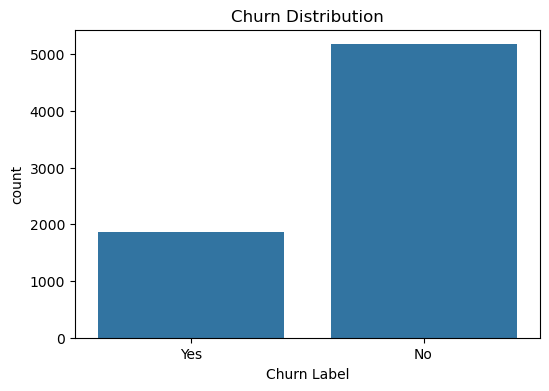

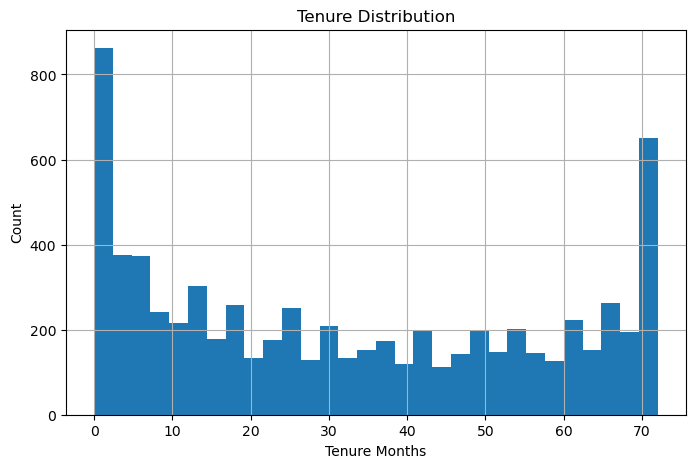

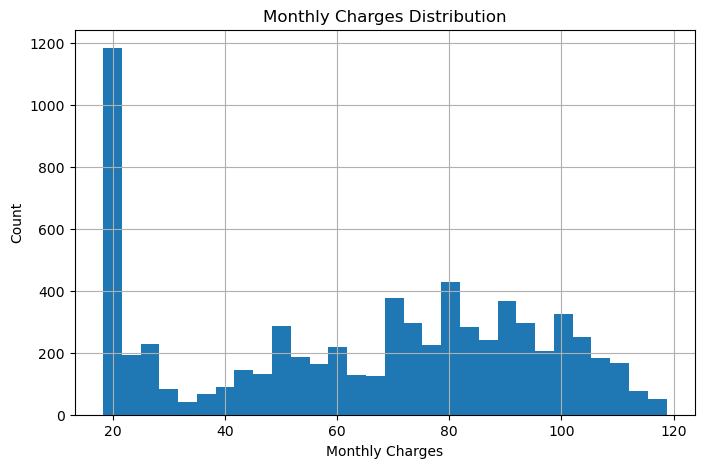


CHURN VS CONTRACT
Churn Label            No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


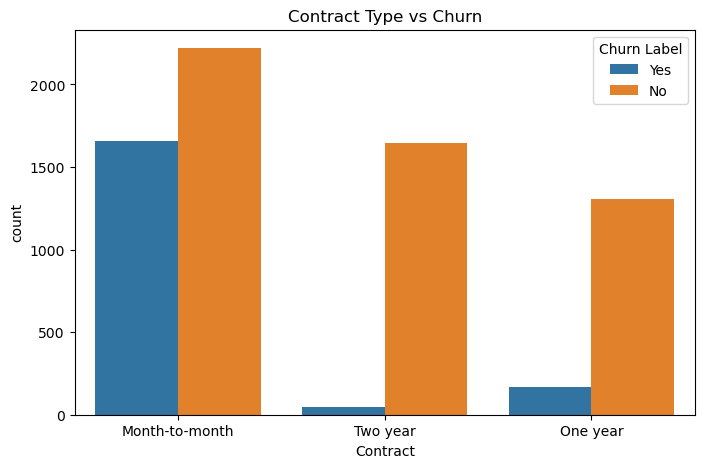


CHURN VS PAYMENT METHOD
Churn Label                       No        Yes
Payment Method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


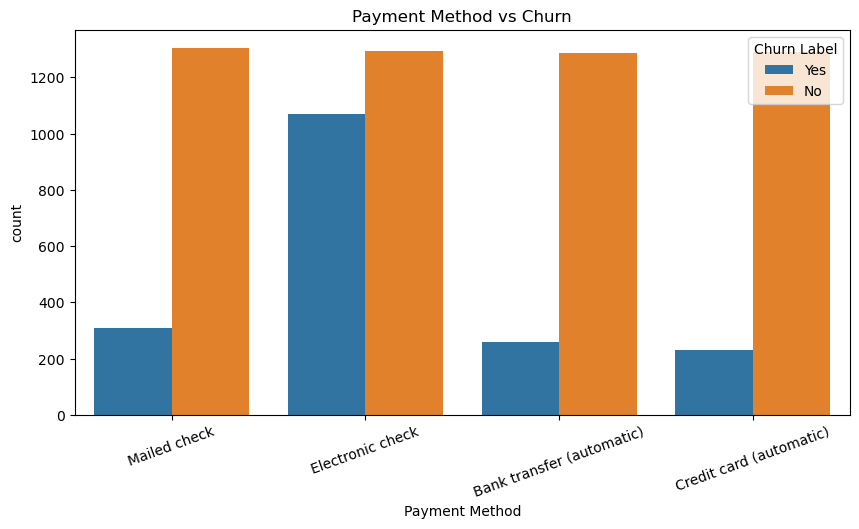


CHURN VS INTERNET SERVICE
Churn Label              No        Yes
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980


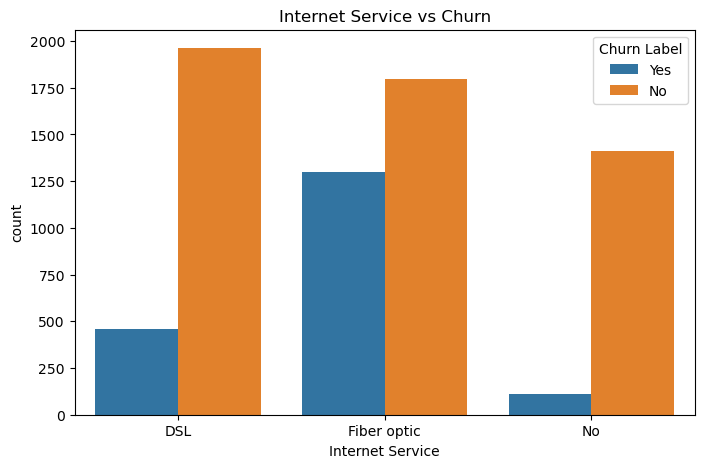

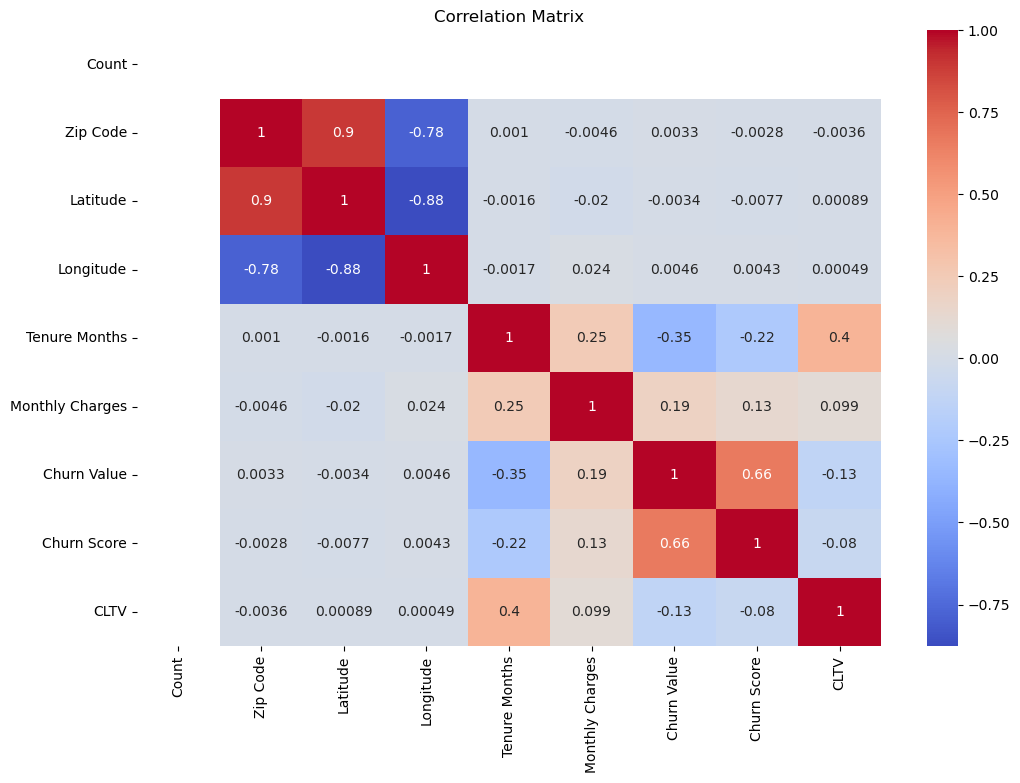

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# TARGET VARIABLE ANALYSIS
# ==============================

print("\n" + "="*50)
print("CHURN DISTRIBUTION")
print("="*50)
print(df['Churn Label'].value_counts())

print("\nPercentage Distribution")
print((df['Churn Label'].value_counts(normalize=True)*100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn Label')
plt.title('Churn Distribution')
plt.show()

# ==============================
# TENURE ANALYSIS
# ==============================

plt.figure(figsize=(8,5))
df['Tenure Months'].hist(bins=30)
plt.title('Tenure Distribution')
plt.xlabel('Tenure Months')
plt.ylabel('Count')
plt.show()

# ==============================
# MONTHLY CHARGES
# ==============================

plt.figure(figsize=(8,5))
df['Monthly Charges'].hist(bins=30)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

# ==============================
# CHURN VS CONTRACT
# ==============================

print("\nCHURN VS CONTRACT")
print(pd.crosstab(
    df['Contract'],
    df['Churn Label'],
    normalize='index'
)*100)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Contract Type vs Churn')
plt.show()

# ==============================
# CHURN VS PAYMENT METHOD
# ==============================

print("\nCHURN VS PAYMENT METHOD")
print(pd.crosstab(
    df['Payment Method'],
    df['Churn Label'],
    normalize='index'
)*100)

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Payment Method', hue='Churn Label')
plt.xticks(rotation=20)
plt.title('Payment Method vs Churn')
plt.show()

# ==============================
# CHURN VS INTERNET SERVICE
# ==============================

print("\nCHURN VS INTERNET SERVICE")
print(pd.crosstab(
    df['Internet Service'],
    df['Churn Label'],
    normalize='index'
)*100)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title('Internet Service vs Churn')
plt.show()

# ==============================
# CORRELATION MATRIX
# ==============================

num_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [15]:
pd.crosstab(
    df['Contract'],
    df['Churn Label'],
    normalize='index'
)*100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [16]:
pd.crosstab(
    df['Internet Service'],
    df['Churn Label'],
    normalize='index'
)*100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [17]:
pd.crosstab(
    df['Payment Method'],
    df['Churn Label'],
    normalize='index'
)*100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


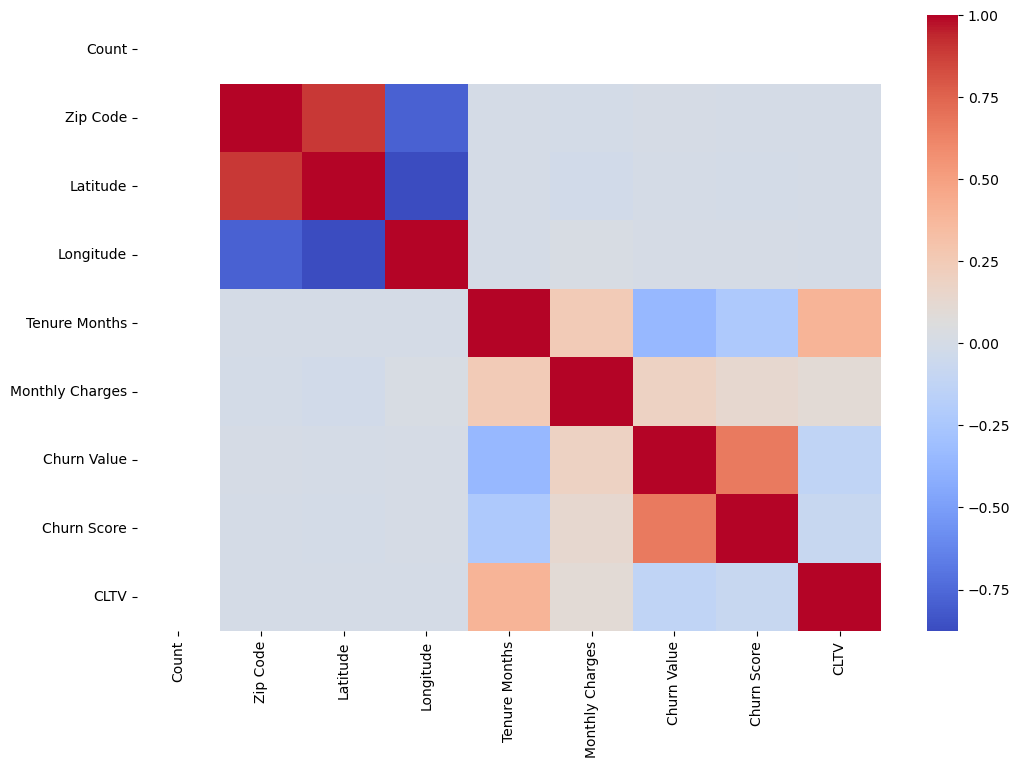

In [18]:
num_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(), cmap='coolwarm')
plt.show()

Correlation Analysis Findings:

Tenure Months shows a negative relationship with churn, indicating that long-term customers are less likely to leave.
Monthly Charges have a slight positive relationship with churn.
CLTV increases with customer tenure.
Churn Score is highly correlated with churn and may cause target leakage if used in model training.
Geographic variables (Zip Code, Latitude, Longitude) are highly related to each other but have little direct relationship with churn.

In [19]:
# ====================================
# DATA PREPROCESSING
# ====================================

import pandas as pd
import numpy as np

# Create copy
df_model = df.copy()

# -----------------------------
# Drop irrelevant columns
# -----------------------------
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV'
]

df_model.drop(columns=drop_cols, inplace=True)

# -----------------------------
# Check missing values
# -----------------------------
print("Missing Values:")
print(df_model.isnull().sum())

# -----------------------------
# Convert target variable
# -----------------------------
df_model['Churn Value'] = df_model['Churn Value'].astype(int)

# -----------------------------
# Identify categorical columns
# -----------------------------
cat_cols = df_model.select_dtypes(include='object').columns

print("\nCategorical Columns:")
print(cat_cols)

# -----------------------------
# One-Hot Encoding
# -----------------------------
df_model = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True
)

print("\nFinal Shape:")
print(df_model.shape)

df_model.head()

Missing Values:
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Value             0
Churn Reason         5174
dtype: int64

Categorical Columns:
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Reason'],
      dtype='object')

Final Shape:
(7043, 6579)


,Tenure Months,Monthly Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Churn Reason_Lack of self-service on Website,Churn Reason_Limited range of services,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction
0,2,53.85,1,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,70.70,1,False,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,False
2,8,99.65,1,False,False,False,True,True,False,True,...,False,False,False,True,False,False,False,False,False,False
3,28,104.80,1,False,False,True,True,True,False,True,...,False,False,False,True,False,False,False,False,False,False
4,49,103.70,1,True,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False


In [20]:
df_model = df.copy()

drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Latitude',
    'Longitude',
    'Lat Long',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

df_model.drop(columns=drop_cols, inplace=True)

df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

print(df_model.shape)

(7043, 6560)


In [21]:
df_model = df.copy()

# Convert Total Charges to numeric
df_model['Total Charges'] = pd.to_numeric(
    df_model['Total Charges'],
    errors='coerce'
)

# Fill any missing values
df_model['Total Charges'].fillna(
    df_model['Total Charges'].median(),
    inplace=True
)

C:\Users\patna\AppData\Local\Temp\ipykernel_25932\1660227847.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['Total Charges'].fillna(


In [22]:
df_model['Total Charges'] = pd.to_numeric(
    df_model['Total Charges'],
    errors='coerce'
)

df_model['Total Charges'] = df_model['Total Charges'].fillna(
    df_model['Total Charges'].median()
)

In [23]:
print(df_model['Total Charges'].dtype)

float64


In [24]:
for col in df_model.select_dtypes(include='object').columns:
    print(f"{col}: {df_model[col].nunique()}")

CustomerID: 7043
Country: 1
State: 1
City: 1129
Lat Long: 1652
Gender: 2
Senior Citizen: 2
Partner: 2
Dependents: 2
Phone Service: 2
Multiple Lines: 3
Internet Service: 3
Online Security: 3
Online Backup: 3
Device Protection: 3
Tech Support: 3
Streaming TV: 3
Streaming Movies: 3
Contract: 3
Paperless Billing: 2
Payment Method: 4
Churn Label: 2
Churn Reason: 20


In [25]:
df_model = df.copy()

# Convert Total Charges
df_model['Total Charges'] = pd.to_numeric(
    df_model['Total Charges'],
    errors='coerce'
)

df_model['Total Charges'] = df_model['Total Charges'].fillna(
    df_model['Total Charges'].median()
)

# Drop leakage and high-cardinality columns
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Latitude',
    'Longitude',
    'Lat Long',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

df_model = df_model.drop(columns=drop_cols)

print(df_model.shape)

# Check remaining object columns
for col in df_model.select_dtypes(include='object').columns:
    print(f"{col}: {df_model[col].nunique()}")

(7043, 20)
Gender: 2
Senior Citizen: 2
Partner: 2
Dependents: 2
Phone Service: 2
Multiple Lines: 3
Internet Service: 3
Online Security: 3
Online Backup: 3
Device Protection: 3
Tech Support: 3
Streaming TV: 3
Streaming Movies: 3
Contract: 3
Paperless Billing: 2
Payment Method: 4


In [26]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

print(df_model.shape)

(7043, 31)


In [27]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn Value', axis=1)
y = df_model['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)

Training Set: (5634, 30)
Test Set: (1409, 30)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.7998580553584103
Precision: 0.6377245508982036
Recall   : 0.56951871657754
F1 Score : 0.6016949152542372

Confusion Matrix
[[914 121]
 [161 213]]


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.7899219304471257
Precision: 0.625
Recall   : 0.5213903743315508
F1 Score : 0.5685131195335277

Confusion Matrix
[[918 117]
 [179 195]]


In [33]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                            Feature  Importance
2                     Total Charges    0.183614
0                     Tenure Months    0.171710
1                   Monthly Charges    0.163463
10     Internet Service_Fiber optic    0.040108
28  Payment Method_Electronic check    0.039615
6                    Dependents_Yes    0.038493
25                Contract_Two year    0.030616
3                       Gender_Male    0.027903
26            Paperless Billing_Yes    0.025269
13              Online Security_Yes    0.024988


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [35]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    print(f"{name}: {scores.mean():.4f}")

C:\Users\patna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\patna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Logistic Regression: 0.8122
Decision Tree: 0.7366
Random Forest: 0.7945
Gradient Boosting: 0.8108


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results

C:\Users\patna\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[['Logistic Regression',
  0.8062455642299503,
  0.6525679758308157,
  0.5775401069518716,
  0.6127659574468085],
 ['Decision Tree',
  0.7295954577714692,
  0.49076517150395776,
  0.49732620320855614,
  0.4940239043824701],
 ['Random Forest',
  0.7899219304471257,
  0.625,
  0.5213903743315508,
  0.5685131195335277],
 ['Gradient Boosting',
  0.8034066713981547,
  0.659016393442623,
  0.5374331550802139,
  0.5920471281296024]]

In [37]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806246,0.652568,0.577540,0.612766
3,Gradient Boosting,0.803407,0.659016,0.537433,0.592047
2,Random Forest,0.789922,0.625000,0.521390,0.568513
1,Decision Tree,0.729595,0.490765,0.497326,0.494024


In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



C:\Users\patna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


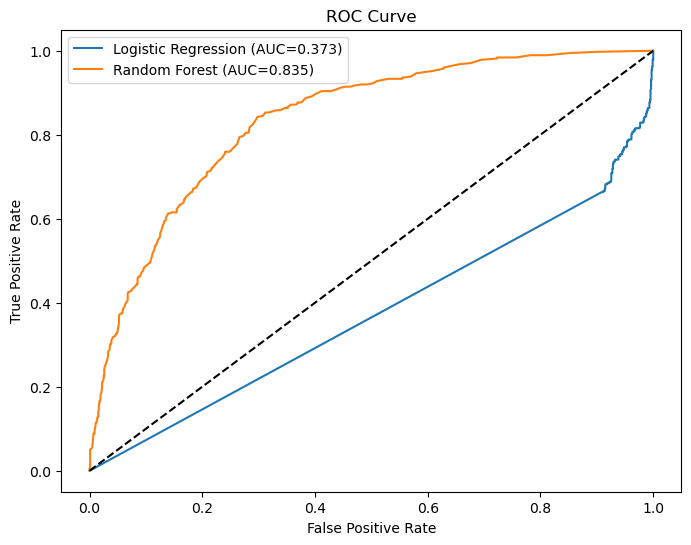

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

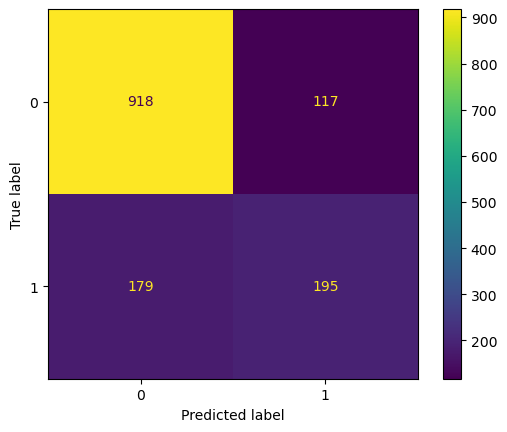

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [43]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42
)

search.fit(X_train,y_train)

print(search.best_params_)
print(search.best_score_)

{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10}
0.589953338467575


prduction pipeline

In [44]:
import joblib

joblib.dump(rf,'churn_model.pkl')

['churn_model.pkl']

In [45]:
loaded_model = joblib.load('churn_model.pkl')

In [46]:
loaded_model.predict(X_test[:5])

array([0, 1, 0, 0, 0])

In [47]:
pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
Note: you may need to restart the kernel to use updated packages.


In [5]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("churn_model.pkl")

st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Customer Churn Prediction")
st.write("Predict whether a telecom customer is likely to churn.")

st.sidebar.header("Customer Information")

# User Inputs
tenure = st.sidebar.slider(
    "Tenure Months",
    0,
    72,
    12
)

monthly_charges = st.sidebar.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=70.0
)

total_charges = st.sidebar.number_input(
    "Total Charges",
    min_value=0.0,
    value=1000.0
)

gender_male = st.sidebar.selectbox(
    "Gender",
    ["Female", "Male"]
)

partner_yes = st.sidebar.selectbox(
    "Partner",
    ["No", "Yes"]
)

dependents_yes = st.sidebar.selectbox(
    "Dependents",
    ["No", "Yes"]
)

# Create input dataframe
input_data = {
    "Tenure Months": tenure,
    "Monthly Charges": monthly_charges,
    "Total Charges": total_charges,
    "Gender_Male": 1 if gender_male=="Male" else 0,
    "Partner_Yes": 1 if partner_yes=="Yes" else 0,
    "Dependents_Yes": 1 if dependents_yes=="Yes" else 0
}

# Add remaining model columns with default 0
for col in model.feature_names_in_:
    if col not in input_data:
        input_data[col] = 0

input_df = pd.DataFrame([input_data])

input_df = input_df[model.feature_names_in_]

if st.button("Predict Churn"):

    prediction = model.predict(input_df)[0]

    probability = model.predict_proba(input_df)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error(
            f"⚠ Customer likely to churn\n\nProbability: {probability:.2%}"
        )
    else:
        st.success(
            f"✅ Customer likely to stay\n\nProbability: {(1-probability):.2%}"
        )

    st.subheader("Input Summary")
    st.dataframe(input_df)

2026-07-05 11:09:45.728 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 11:09:45.730 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 11:09:46.142 
  command:

    streamlit run C:\Users\patna\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-05 11:09:46.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 11:09:46.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 11:09:46.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 11:09:46.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [6]:
import joblib

joblib.dump(
    search.best_estimator_,
    "churn_model.pkl"
)

NameError: name 'search' is not defined

In [7]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [8]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.venv',
 'app',
 'churn_analysis.ipynb',
 'churn_model.pkl',
 'data',
 'models',
 'notebooks',
 'README.md',
 'requirements.txt',
 'sample_customers.csv']

In [9]:
import os
os.listdir("app")

['.ipynb_checkpoints', 'app.py']

In [10]:
import joblib

model = joblib.load("churn_model.pkl")

print(model)

Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=10, min_samples_split=10,
                                        n_estimators=300, random_state=42))])


In [11]:
print(model.feature_names_in_)

['Tenure Months' 'Monthly Charges' 'Total Charges' 'Gender_Male'
 'Senior Citizen_Yes' 'Partner_Yes' 'Dependents_Yes' 'Phone Service_Yes'
 'Multiple Lines_No phone service' 'Multiple Lines_Yes'
 'Internet Service_Fiber optic' 'Internet Service_No'
 'Online Security_No internet service' 'Online Security_Yes'
 'Online Backup_No internet service' 'Online Backup_Yes'
 'Device Protection_No internet service' 'Device Protection_Yes'
 'Tech Support_No internet service' 'Tech Support_Yes'
 'Streaming TV_No internet service' 'Streaming TV_Yes'
 'Streaming Movies_No internet service' 'Streaming Movies_Yes'
 'Contract_One year' 'Contract_Two year' 'Paperless Billing_Yes'
 'Payment Method_Credit card (automatic)'
 'Payment Method_Electronic check' 'Payment Method_Mailed check']


In [12]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("model", search.best_estimator_)
])

joblib.dump(pipeline, "churn_model.pkl")

NameError: name 'search' is not defined

In [13]:
import joblib

model = joblib.load("churn_model.pkl")

print(model)

Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=10, min_samples_split=10,
                                        n_estimators=300, random_state=42))])


In [14]:
print(len(model.named_steps["model"].feature_names_in_))

30


In [15]:
sample = X_test.iloc[:5]

preds = model.predict(sample)

print(preds)

NameError: name 'X_test' is not defined

In [16]:
sample = X_test.iloc[:5]

preds = model.predict(sample)

print(preds)

NameError: name 'X_test' is not defined

In [17]:
sample = X_test.iloc[:20]

sample.to_csv("sample_customers.csv", index=False)

print("saved")

NameError: name 'X_test' is not defined

In [18]:
import os

print(os.listdir())

['.ipynb_checkpoints', '.venv', 'app', 'churn_analysis.ipynb', 'churn_model.pkl', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'sample_customers.csv']


In [19]:
sample = X_test.iloc[:20]

NameError: name 'X_test' is not defined

In [20]:
!streamlit run app/app.py

^C


In [21]:
%%writefile app/app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

st.set_page_config(
    page_title="ChurnSense",
    page_icon="📊",
    layout="wide"
)

# ---------------- PATHS ----------------

BASE_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = BASE_DIR / "churn_model.pkl"
DATA_PATH = BASE_DIR / "sample_customers.csv"

# ---------------- LOAD FILES ----------------

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

@st.cache_data
def load_data():
    return pd.read_csv(DATA_PATH)

model = load_model()
df = load_data()

# ---------------- SIDEBAR ----------------

st.sidebar.title("📊 ChurnSense")
st.sidebar.caption("AI-Powered Customer Churn Analytics")

page = st.sidebar.radio(
    "Navigation",
    [
        "🏠 Dashboard",
        "🔮 Predict",
        "📁 Batch",
        "📊 Analytics"
    ]
)

st.sidebar.divider()
st.sidebar.caption("Machine Learning Churn Prediction System")


# =========================================================
# DASHBOARD PAGE
# =========================================================

if page == "🏠 Dashboard":

    st.title("🏠 Customer Churn Dashboard")
    st.caption("Customer risk monitoring and churn analytics")

    probabilities = model.predict_proba(df)[:, 1]
    predictions = model.predict(df)

    total_customers = len(df)
    predicted_churn = int(predictions.sum())
    churn_rate = predictions.mean()
    avg_probability = probabilities.mean()

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Customers",
        f"{total_customers:,}"
    )

    col2.metric(
        "At-Risk Customers",
        f"{predicted_churn:,}"
    )

    col3.metric(
        "Predicted Churn Rate",
        f"{churn_rate:.1%}"
    )

    col4.metric(
        "Average Churn Risk",
        f"{avg_probability:.1%}"
    )

    st.divider()

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("Customer Risk Distribution")

        risk_labels = pd.cut(
            probabilities,
            bins=[0, 0.30, 0.70, 1],
            labels=["Low Risk", "Medium Risk", "High Risk"],
            include_lowest=True
        )

        risk_counts = risk_labels.value_counts()

        st.bar_chart(risk_counts)

    with col2:

        st.subheader("Prediction Distribution")

        prediction_counts = pd.Series(
            predictions
        ).map({
            0: "Stay",
            1: "Churn"
        }).value_counts()

        st.bar_chart(prediction_counts)

    st.divider()

    st.subheader("High-Risk Customer Watchlist")

    dashboard_df = df.copy()

    dashboard_df["Churn Probability"] = probabilities

    dashboard_df["Risk Level"] = pd.cut(
        probabilities,
        bins=[0, 0.30, 0.70, 1],
        labels=["Low", "Medium", "High"],
        include_lowest=True
    )

    high_risk = dashboard_df.sort_values(
        "Churn Probability",
        ascending=False
    ).head(10)

    st.dataframe(
        high_risk,
        use_container_width=True
    )


# =========================================================
# PREDICT PAGE
# =========================================================

elif page == "🔮 Predict":

    st.title("🔮 Single Customer Prediction")
    st.caption("Predict churn risk for an individual customer")

    customer_id = st.number_input(
        "Select Customer Row",
        min_value=0,
        max_value=len(df) - 1,
        value=0,
        step=1
    )

    customer = df.iloc[[customer_id]]

    st.subheader("Customer Profile")

    profile_col1, profile_col2, profile_col3 = st.columns(3)

    profile_col1.metric(
        "Tenure",
        f"{customer['Tenure Months'].iloc[0]} months"
    )

    profile_col2.metric(
        "Monthly Charges",
        f"${customer['Monthly Charges'].iloc[0]:.2f}"
    )

    profile_col3.metric(
        "Total Charges",
        f"${customer['Total Charges'].iloc[0]:.2f}"
    )

    with st.expander("View Complete Customer Features"):

        st.dataframe(
            customer,
            use_container_width=True
        )

    if st.button(
        "Predict Churn",
        type="primary",
        use_container_width=True
    ):

        prediction = model.predict(customer)[0]

        probability = model.predict_proba(
            customer
        )[0][1]

        if probability < 0.30:

            risk = "Low Risk"

        elif probability < 0.70:

            risk = "Medium Risk"

        else:

            risk = "High Risk"

        st.divider()

        st.subheader("Prediction Results")

        col1, col2, col3 = st.columns(3)

        col1.metric(
            "Churn Probability",
            f"{probability:.2%}"
        )

        col2.metric(
            "Risk Level",
            risk
        )

        col3.metric(
            "Prediction",
            "CHURN" if prediction == 1 else "STAY"
        )

        st.progress(float(probability))

        if prediction == 1:

            st.error(
                "⚠️ Customer is predicted to churn."
            )

            st.subheader("💡 Retention Recommendations")

            st.markdown("""
            - Contact the customer proactively.
            - Offer a personalised loyalty discount.
            - Review billing and service concerns.
            - Recommend a long-term contract.
            - Provide targeted service bundles.
            """)

        else:

            st.success(
                "✅ Customer is predicted to stay."
            )

            st.subheader("💡 Engagement Recommendations")

            st.markdown("""
            - Maintain current service quality.
            - Continue customer engagement.
            - Consider premium service upselling.
            - Offer loyalty rewards.
            """)


# =========================================================
# BATCH PAGE
# =========================================================

elif page == "📁 Batch":

    st.title("📁 Batch Churn Prediction")
    st.caption("Upload customer data and generate churn predictions")

    uploaded_file = st.file_uploader(
        "Upload Customer CSV",
        type=["csv"]
    )

    if uploaded_file is not None:

        batch_df = pd.read_csv(uploaded_file)

        st.subheader("Uploaded Data")

        st.dataframe(
            batch_df.head(),
            use_container_width=True
        )

        expected_columns = list(
            model.named_steps["model"].feature_names_in_
        )

        missing_columns = [
            col
            for col in expected_columns
            if col not in batch_df.columns
        ]

        if missing_columns:

            st.error(
                "CSV does not contain all required model features."
            )

            st.write(
                "Missing columns:",
                missing_columns
            )

        else:

            batch_df = batch_df[expected_columns]

            if st.button(
                "Run Batch Prediction",
                type="primary"
            ):

                predictions = model.predict(batch_df)

                probabilities = model.predict_proba(
                    batch_df
                )[:, 1]

                results = batch_df.copy()

                results["Prediction"] = predictions

                results["Churn Status"] = pd.Series(
                    predictions
                ).map({
                    0: "Stay",
                    1: "Churn"
                })

                results["Churn Probability"] = probabilities

                results["Risk Level"] = pd.cut(
                    probabilities,
                    bins=[0, 0.30, 0.70, 1],
                    labels=[
                        "Low",
                        "Medium",
                        "High"
                    ],
                    include_lowest=True
                )

                st.success(
                    f"Predictions completed for {len(results)} customers."
                )

                st.subheader("Prediction Results")

                st.dataframe(
                    results,
                    use_container_width=True
                )

                csv = results.to_csv(
                    index=False
                ).encode("utf-8")

                st.download_button(
                    "⬇️ Download Prediction Results",
                    data=csv,
                    file_name="churn_predictions.csv",
                    mime="text/csv"
                )


# =========================================================
# ANALYTICS PAGE
# =========================================================

elif page == "📊 Analytics":

    st.title("📊 Model Analytics")
    st.caption("Machine learning model performance and insights")

    st.subheader("Model Information")

    model_name = type(
        model.named_steps["model"]
    ).__name__

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Model",
        model_name
    )

    col2.metric(
        "Input Features",
        len(
            model.named_steps[
                "model"
            ].feature_names_in_
        )
    )

    col3.metric(
        "Training Algorithm",
        "Random Forest"
    )

    st.divider()

    st.subheader("Model Configuration")

    estimator = model.named_steps["model"]

    config_df = pd.DataFrame({
        "Parameter": [
            "Number of Trees",
            "Maximum Depth",
            "Minimum Samples Split",
            "Random State"
        ],
        "Value": [
            estimator.n_estimators,
            estimator.max_depth,
            estimator.min_samples_split,
            estimator.random_state
        ]
    })

    st.dataframe(
        config_df,
        use_container_width=True,
        hide_index=True
    )

    st.divider()

    st.subheader("Feature Importance")

    feature_names = estimator.feature_names_in_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": estimator.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    top_features = importance_df.head(10)

    st.bar_chart(
        top_features.set_index("Feature")
    )

    st.subheader("Top Predictive Features")

    st.dataframe(
        top_features,
        use_container_width=True,
        hide_index=True
    )

Overwriting app/app.py


In [22]:
!streamlit run app/app.py

^C
